<a href="https://colab.research.google.com/github/EmilKarimov3/Emil_INFO4670_Fall2026/blob/main/INFO4670_Week3_Assignment1_Emil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1 — Making Sense of Northgate through Visualization
**INFO 4670 · Data Analysis and Knowledge Discovery**  ·  **Due: Sunday, 11:59 PM**

**Name:** \_\_\_\_\_\_\_\_    **Date:** \_\_\_\_\_\_\_\_

**The situation.** The Provost's question stands: *which students are struggling, and can we see it earlier?* This week you answer it the way analysts do — not by reading rows, but by drawing the data. Every chart below is built by **adapting code from the Guided notebook**; the intellectual work is choosing the right chart and reading it honestly.

**For every chart you make, you must:**
1. **Choose** the chart type that fits the variable(s) and the question.
2. **Build** it in Colab from the Northgate files.
3. **Label** it fully — title, axis labels, and units/legend. *An unlabeled chart is an unfinished chart.*
4. **Write a STAR story** underneath it — Scope · Track · Articulate · Respond (defined on the Concepts deck).

**How to work:** run Setup and Load first. Then, for each question, copy the closest cell from the Guided notebook into the empty cell, adapt it, and fill in the STAR cell below it.

**Submit:** push this notebook to GitHub and submit the **GitHub link** in Canvas. (See the setup doc: *Colab_GitHub_Setup_INFO4670_Fall2026*.)

## Setup — run this first (you don't need to change it)

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Northgate house style (optional, but keeps your charts consistent)
NAVY = "#22303A"
RUST = "#C0562F"
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"]   = (8, 5)
plt.rcParams["axes.titlesize"]   = 13
plt.rcParams["axes.titleweight"] = "bold"

## Load the data — run this, then look before you plot

In [21]:
# STEP 1 — get the data into this notebook. Pick ONE option, then run.

# DATA_DIR = "."   # OPTION 2 (default) · drag the 3 CSVs into the file panel on the left

# OPTION 1 · read from Google Drive — uncomment and edit the path:
# from google.colab import drive
# drive.mount("/content/drive") # This has already been run in previous cells, so it's not strictly necessary here, but keeping it commented for context.
DATA_DIR = "." # <--- EDIT THIS PATH to your data's location in Google Drive

import os
students = pd.read_csv(os.path.join(DATA_DIR, "student_records.csv"))
weekly   = pd.read_csv(os.path.join(DATA_DIR, "weekly_activity.csv"))
students.head()

,student_id,major,age,housing,commute_miles,work_hours_per_week,advisor_meetings,credits_attempted,final_gpa,study_hours_reported,enrollment_date,dropped_out
0,NU-101508,Data Science,27,Off-Campus,7.6,15,1,81,1.86,NaN,2023-09-13,1
1,NU-102438,Learning Technologies,25,With Family,14.3,35,1,100,2.06,9.5,2023-10-19,0
2,NU-102385,Learning Technologies,26,With Family,3.4,18,9,77,3.41,19.1,11/16/2022,0
3,NU-100767,Cyber Security,22,On-Campus,23.7,40,1,65,1.73,8.1,2024-05-03,0
4,NU-106054,Information Technology,21,Off-Campus,2.3,20,4,59,2.37,6.6,10/24/2022,0


### How to find your data files in Google Drive:

1.  **List contents of your Google Drive:** Run the following cell to see the top-level folders in your mounted Google Drive. The `MyDrive` folder is usually where your personal files are.
2.  **Navigate deeper:** If your files are in a subfolder, modify the `!ls` command (e.g., `!ls /content/drive/MyDrive/YourFolder`) to go deeper into your directory structure.
3.  **Identify the full path:** Once you locate the folder containing `student_records.csv` and `weekly_activity.csv`, the full path to that folder is what you should use for `DATA_DIR`.

For example, if your files are in `MyDrive/Colab Notebooks/my_data_folder`, your `DATA_DIR` would be `'/content/drive/MyDrive/Colab Notebooks/my_data_folder'`.

In [22]:
# Use `!ls` to list the contents of your Google Drive.
# Start by listing the contents of the mounted drive:
!ls /content/drive/MyDrive

# If your files are in a subfolder, you can navigate further, for example:
# !ls /content/drive/MyDrive/YourFolderName
# !ls /content/drive/MyDrive/YourFolderName/AnotherSubFolder

ls: cannot access '/content/drive/MyDrive': No such file or directory


### File Verification
Use the cell below to confirm Colab can see your files. Replace the path with the one you identified in the previous step.

In [23]:
import os

# Replace this path with the folder you found
MY_DATA_PATH = "/content/drive/MyDrive/.../Data"

files_to_check = ["student_records.csv", "weekly_activity.csv"]

for file_name in files_to_check:
    full_path = os.path.join(MY_DATA_PATH, file_name)
    if os.path.exists(full_path):
        print(f"✅ FOUND: {file_name}")
    else:
        print(f"❌ MISSING: {file_name} (Checked path: {full_path})")

❌ MISSING: student_records.csv (Checked path: /content/drive/MyDrive/.../Data/student_records.csv)
❌ MISSING: weekly_activity.csv (Checked path: /content/drive/MyDrive/.../Data/weekly_activity.csv)


In [24]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
# how many rows, which columns, what types?
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2027 entries, 0 to 2026
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            2027 non-null   object 
 1   major                 2027 non-null   object 
 2   age                   2027 non-null   int64  
 3   housing               2027 non-null   object 
 4   commute_miles         2027 non-null   float64
 5   work_hours_per_week   2027 non-null   int64  
 6   advisor_meetings      2027 non-null   int64  
 7   credits_attempted     2027 non-null   int64  
 8   final_gpa             2027 non-null   float64
 9   study_hours_reported  1772 non-null   float64
 10  enrollment_date       2027 non-null   object 
 11  dropped_out           2027 non-null   int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 190.2+ KB


# Part A — Guided questions
Build **one chart per question**. Each maps to one chart family from this week. Copy the closest Guided-notebook cell, adapt it, label it, then write its STAR story.

### Q1 · One quantitative variable
**How many hours per week do Northgate students work?** Describe what's typical, how spread out it is, and whether anyone stands apart.
→ *histogram* (add a *box plot* if it helps). Column: `work_hours_per_week` (from `students`).

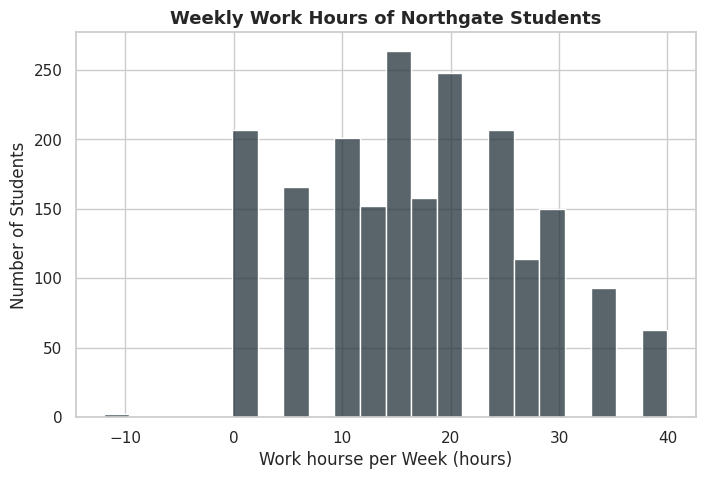

In [27]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
#   fig, ax = plt.subplots()
#   sns.__________(data=________, x="__________", color=NAVY, ax=ax)   # which chart? which column(s)?
#   ax.set_title("__________")
#   ax.set_xlabel("__________")
#   ax.set_ylabel("__________")
#   plt.show()

# --- your code below ---
fig, ax = plt.subplots()
sns.histplot(data=students, x="work_hours_per_week", color=NAVY, ax=ax)
ax.set_title("Weekly Work Hours of Northgate Students")
ax.set_xlabel("Work hourse per Week (hours)")
ax.set_ylabel("Number of Students")

plt.show()

In [28]:
students["work_hours_per_week"].describe()

,work_hours_per_week
count,2027.000000
mean,17.284164
std,10.401333
min,-12.000000
25%,10.000000
50%,18.000000
75%,25.000000
max,40.000000


**Scope:** This histogram displays the number of hours worked per week for 2,027 students at Northgate. **Track:** I want to learn the number of hours worked per week by students and if any data are noteworthy. **Articulate:** Approximately 18 hours per week is a typical number of hours worked by a student. About 50% of students work between 10 and 25 hours per week. −12 hours of weekly work is noteworthy since it is not possible to work a negative number of hours per week. **Respond:** I would look at the original data to verify this value before making a decision based on this.

**STAR story — Q1** *(write in your own words)*

- **Scope —** what does this chart show? (which column(s), which students)
- **Track —** which question are you answering?
- **Articulate —** what does the chart actually say? (typical value, spread, shape, comparison, or trend)
- **Respond —** anything odd or unexpected? what would you look at next? *(note it — you don't fix it this week)*

### Q2 · One categorical variable
**How does enrollment compare across majors?**
→ *sorted bar chart*. Column: `major` (from `students`).

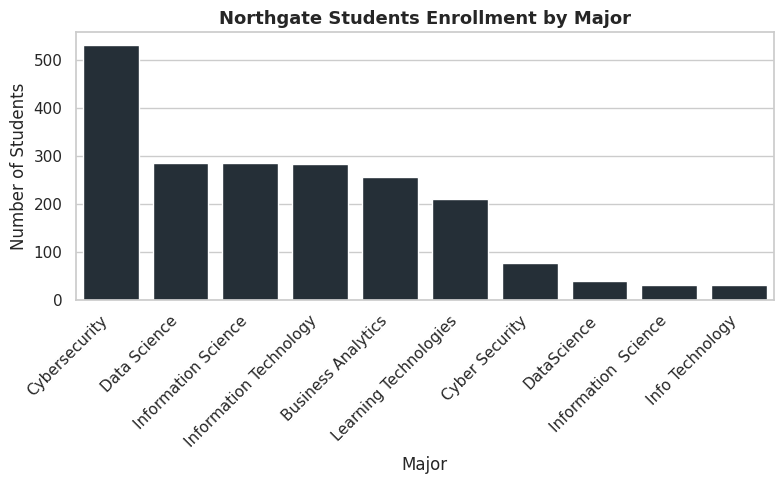

In [29]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
#   fig, ax = plt.subplots()
#   sns.__________(data=________, x="__________", color=NAVY, ax=ax)   # which chart? which column(s)?
#   ax.set_title("__________")
#   ax.set_xlabel("__________")
#   ax.set_ylabel("__________")
#   plt.show()

# --- your code below ---
major_counts = (
    students["major"]
    .value_counts()
    .sort_values(ascending=False)
    .rename_axis("major")
    .reset_index(name="Number of Students")
)

fig, ax = plt.subplots()
sns.barplot(
    data=major_counts,
    x="major",
    y="Number of Students",
    color=NAVY,
    ax=ax
)

ax.set_title("Northgate Students Enrollment by Major")
ax.set_xlabel("Major")
ax.set_ylabel("Number of Students")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Scope:** This sorted bar chart displays the number of students enrolled in each major at Northgate. **Track:** This chart displays enrollment per major. **Articulate:** Cybersecurity has the most enrollment. The majors Cybersecurity and Cyber Security seem to be the same major but are listed separately. The same can be said for DataScience and Data Science. This can make the data less useful for comparing enrollments. **Respond:** I would first clean and standardize the major names before utilizing this chart for making enrollment choices.

**STAR story — Q2** *(write in your own words)*

- **Scope —** what does this chart show? (which column(s), which students)
- **Track —** which question are you answering?
- **Articulate —** what does the chart actually say? (typical value, spread, shape, comparison, or trend)
- **Respond —** anything odd or unexpected? what would you look at next? *(note it — you don't fix it this week)*

### Q3 · A quantity, split by category
**Does final GPA differ across majors?** Read the exceptions, not just the boxes.
→ *box plot per major*. Columns: `final_gpa` and `major` (from `students`).

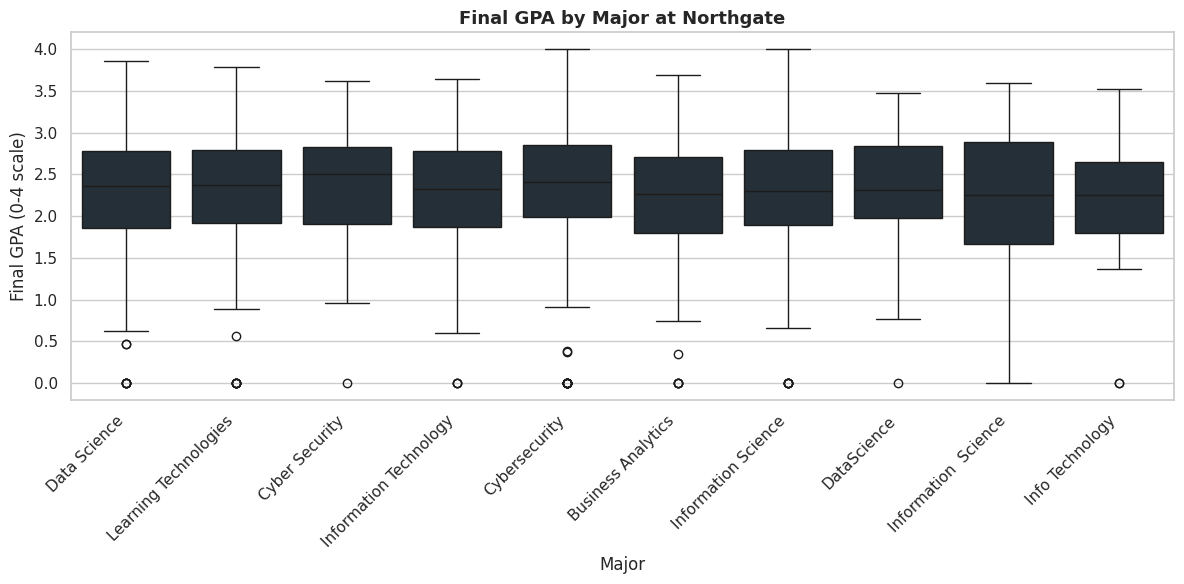

In [30]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
#   fig, ax = plt.subplots()
#   sns.__________(data=________, x="__________", color=NAVY, ax=ax)   # which chart? which column(s)?
#   ax.set_title("__________")
#   ax.set_xlabel("__________")
#   ax.set_ylabel("__________")
#   plt.show()

# --- your code below ---
fig, ax = plt.subplots(figsize=(12,6))
sns.boxplot(
    data=students,
    x="major",
    y="final_gpa",
    color=NAVY,
    ax=ax
)

ax.set_title("Final GPA by Major at Northgate")
ax.set_xlabel("Major")
ax.set_ylabel("Final GPA (0-4 scale)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**STAR story — Q3** *(write in your own words)*

- **Scope —** what does this chart show? (which column(s), which students)
- **Track —** which question are you answering?
- **Articulate —** what does the chart actually say? (typical value, spread, shape, comparison, or trend)
- **Respond —** anything odd or unexpected? what would you look at next? *(note it — you don't fix it this week)*

**Scope:** This box plot displays final GPA for majors at Northgate. **Track:** We are interested in determining if there are differences in final GPA among the majors. **Articulate:** The median GPAs are all in the low to mid 2s and do not appear to significantly differ between the majors. However, many majors contain some data points with very low GPAs close to zero which appear to differ significantly from the rest of the data in that major. **Respond:** I would be interested in looking at these low GPA values and other variables (class attendance, number of hours worked, etc.) rather than automatically attributing GPAs to a student based on their major.

### Q4 · Two quantitative variables
**Is there a relationship between how far students commute and their final GPA?** Remember: *association is not causation.*
→ *scatterplot with a trend line*. Columns: `commute_miles` and `final_gpa` (from `students`).

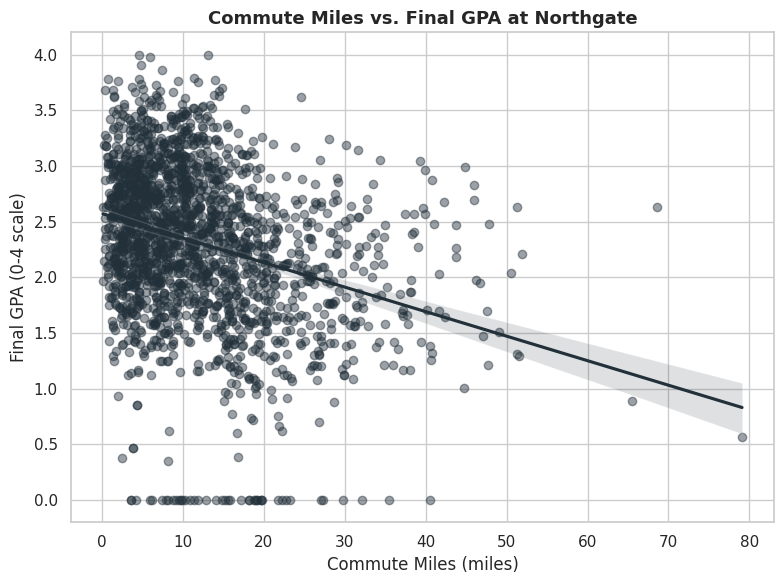

In [31]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
#   fig, ax = plt.subplots()
#   sns.__________(data=________, x="__________", color=NAVY, ax=ax)   # which chart? which column(s)?
#   ax.set_title("__________")
#   ax.set_xlabel("__________")
#   ax.set_ylabel("__________")
#   plt.show()

# --- your code below ---
fig, ax = plt.subplots(figsize=(8,6))

sns.regplot(
    data=students,
    x="commute_miles",
    y="final_gpa",
    color=NAVY,
    scatter_kws={"alpha":0.45},
    ax=ax
)

ax.set_title("Commute Miles vs. Final GPA at Northgate")
ax.set_xlabel("Commute Miles (miles)")
ax.set_ylabel("Final GPA (0-4 scale)")
plt.tight_layout()
plt.show()


**STAR story — Q4** *(write in your own words)*

- **Scope —** what does this chart show? (which column(s), which students)
- **Track —** which question are you answering?
- **Articulate —** what does the chart actually say? (typical value, spread, shape, comparison, or trend)
- **Respond —** anything odd or unexpected? what would you look at next? *(note it — you don't fix it this week)*

**Scope:** This scatterplot relates commute distance in miles to final GPA at Northgate. **Track:** I want to see if longer commutes are related to different final GPAs. **Articulate:** There is a negative relationship because the trend line goes down. This would indicate that the more miles a student commutes the lower their final GPA turns out to be within this data set. The data points are spread out fairly across the graph, so there is not a direct relationship between commute and GPA. Some commutes are significantly longer than others and some GPAs are zero. **Respond:** I would examine the data for zero GPAs and consider additional factors like hours of work and activity. Also this relationship does not necessarily mean that increasing commute length results in a decreasing GPA.

### Q5 · Over time
**How does student engagement change across the semester?**
→ *line chart* of average weekly activity. Use the `weekly` table: `week` and `minutes_active` (you'll need to average by week first — see the Guided notebook).

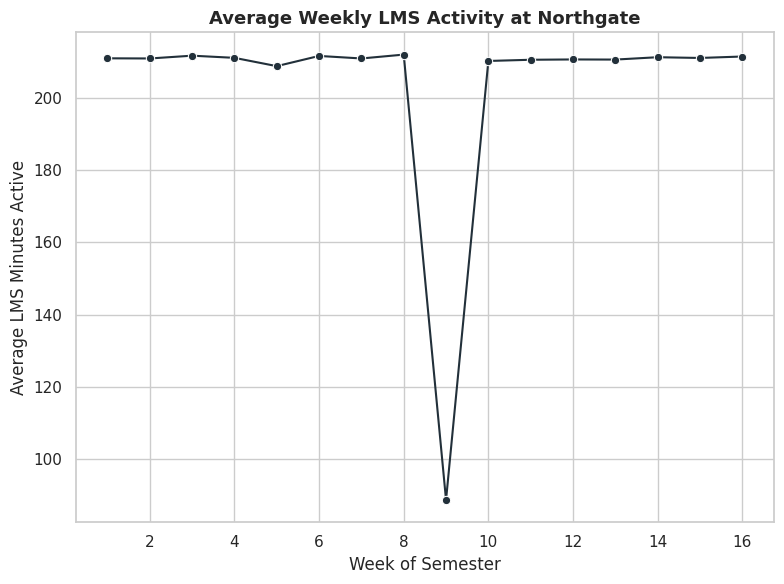

In [32]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
#   fig, ax = plt.subplots()
#   sns.__________(data=________, x="__________", color=NAVY, ax=ax)   # which chart? which column(s)?
#   ax.set_title("__________")
#   ax.set_xlabel("__________")
#   ax.set_ylabel("__________")
#   plt.show()

# --- your code below ---
weekly_averages = (
    weekly.groupby("week", as_index=False)["minutes_active"]
    .mean()
    .sort_values("week")
)

fig, ax = plt.subplots(figsize=(8,6))
sns.lineplot(
    data=weekly_averages,
    x="week",
    y="minutes_active",
    marker="o",
    color=NAVY,
    ax=ax
)

ax.set_title("Average Weekly LMS Activity at Northgate")
ax.set_xlabel("Week of Semester")
ax.set_ylabel("Average LMS Minutes Active")
plt.tight_layout()
plt.show()

**STAR story — Q5** *(write in your own words)*

- **Scope —** what does this chart show? (which column(s), which students)
- **Track —** which question are you answering?
- **Articulate —** what does the chart actually say? (typical value, spread, shape, comparison, or trend)
- **Respond —** anything odd or unexpected? what would you look at next? *(note it — you don't fix it this week)*

**Scope:** This line chart displays the mean number of LMS minutes that students at Northgate have been active for each week in the semester. **Track:** This chart tracks the level of student activity over time. **Articuate:** For the majority of weeks there is relatively constant activity around 210 minutes. Week 9 however displays a sharp decrease to around 90 minutes only to return to constant activity in Week 10. There is not a general decrease in activity throughout the semester. **Respond:** I would first look at Week 9 to determine if there was a break in activity, an issue within the LMS, or data loss for activities prior to making conclusions about the decrease in activity.

# Part B — Your own question (open)
Pose **one question of your own** about the Northgate students, choose the chart that answers it, build it, label it, and write its STAR story. Going beyond Part A is rewarded — a per-student line chart, a violin plot, or a chart of a messier column are all fair game.

**Your question:** \_\_\_\_\_\_\_\_



How does commute distance differ by housing status?

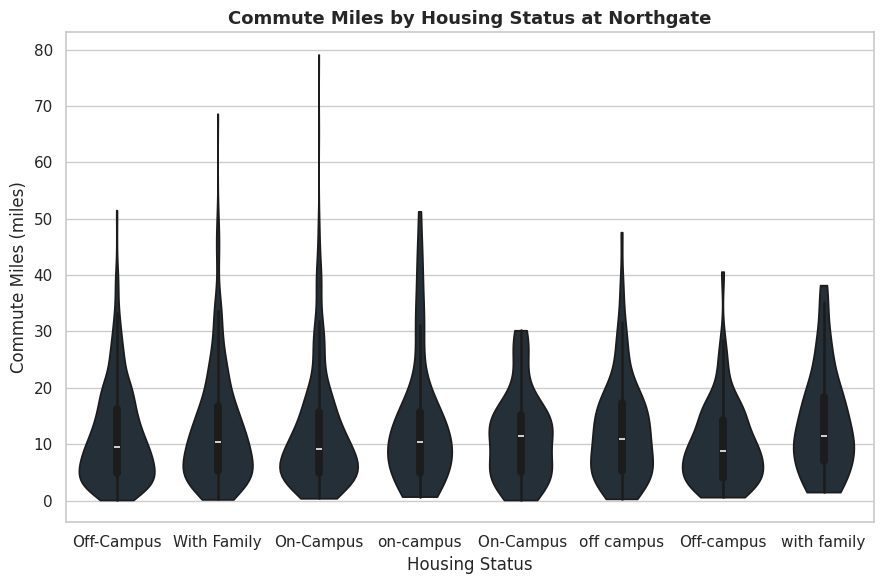

In [33]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
#   fig, ax = plt.subplots()
#   sns.__________(data=________, x="__________", color=NAVY, ax=ax)   # which chart? which column(s)?
#   ax.set_title("__________")
#   ax.set_xlabel("__________")
#   ax.set_ylabel("__________")
#   plt.show()

# --- your code below ---
fig, ax = plt.subplots(figsize=(9,6))

sns.violinplot(
    data=students,
    x="housing",
    y="commute_miles",
    color=NAVY,
    inner="box",
    cut=0,
    ax=ax
)

ax.set_title("Commute Miles by Housing Status at Northgate")
ax.set_xlabel("Housing Status")
ax.set_ylabel("Commute Miles (miles)")
plt.tight_layout()
plt.show()

**Scope:** This violin plot displays the commute mileage data for Northgate students by housing type. **Track:** I want to compare commute by housing type. **Articulate:** The mean commute values are quite comparable between the housing types, but there are some extreme values that represent students with long commutes. There is a value for a student who is on campus and has a commute of nearly 80 miles. Additionally, there are instances of housing values being repeated, like “Off-Campus” and “off campus.” These housing types might actually represent the same housing type. **Respond:** I would first look at cleaning the housing values and then look at the long value for a commute. Once this is done, this plot can be used to compare housing types.

**STAR story — Part B** *(write in your own words)*

- **Scope —** what does this chart show? (which column(s), which students)
- **Track —** which question are you answering?
- **Articulate —** what does the chart actually say? (typical value, spread, shape, comparison, or trend)
- **Respond —** anything odd or unexpected? what would you look at next? *(note it — you don't fix it this week)*

# Before you submit — checklist
- [ ] The notebook **runs top to bottom** with no errors (Runtime → Restart and run all).
- [ ] All **6 charts** are present, each with a title, labeled axes, and units/legend where needed.
- [ ] Each chart has a **complete STAR story**, including any exceptions you spotted.
- [ ] Part B question is written in and answered.
- [ ] Pushed to **GitHub**, and the **GitHub link** is submitted in Canvas.

**Rubric (70 pts):** chart choice 10 · correct build 20 · labeling 10 · STAR reading 18 · Part B question 4 · submission & professionalism 8.